In [4]:
import laspy
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import open3d as o3d
import sys


Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.


### Data loading and processing 

In [10]:
import laspy
import pandas as pd
import numpy as np
import seaborn as sns
import open3d as o3d

def point_cloud_to_dataframe(
    file_path: str,
    apply_scale: bool = True) -> pd.DataFrame:
    file_ext = file_path.lower().split('.')[-1]
    
    if file_ext in ['las', 'laz']:
        return _las_to_dataframe(file_path, apply_scale=apply_scale)  
    elif file_ext == 'pcd':
        return _pcd_to_dataframe(file_path)
    else:
        raise ValueError(f"Unsupported file format: .{file_ext}. Supported: .las, .laz, .pcd")


def _las_to_dataframe(las_path: str, apply_scale: bool = True) -> pd.DataFrame:
    """
    Loads .las/.laz file and converts it to a pandas DataFrame.
    """
    print(f"📂 Loading LAS/LAZ file: {las_path}")
    las = laspy.read(las_path)

    print(f"Number of points: {las.header.point_count:,}")

    dims = [dim.name for dim in las.point_format.dimensions]
    print(f"Detected dimensions: {dims}")

    data = {}
    for dim in dims:
        try:
            arr = getattr(las, dim)
            data[dim] = np.array(arr)
        except AttributeError:
            print(f"Field '{dim}' is not found.")
            continue

    df = pd.DataFrame(data)
    if apply_scale:
        sx, sy, sz = las.header.scales
        ox, oy, oz = las.header.offsets

        if "X" in df.columns:
            df["X"] = df["X"].astype(np.float64) * sx + ox
        if "Y" in df.columns:
            df["Y"] = df["Y"].astype(np.float64) * sy + oy
        if "Z" in df.columns:
            df["Z"] = df["Z"].astype(np.float64) * sz + oz

        print("Applied LAS header scale+offset to X,Y,Z.")
    else:
        print("Kept raw LAS X,Y,Z (no header scale+offset applied).")
    
    print(f"DataFrame created. Shape: {df.shape}")
    return df


def _pcd_to_dataframe(pcd_path: str) -> pd.DataFrame:
    """
    Loads .pcd file and converts it to a pandas DataFrame.
    """
    print(f"📂 Loading PCD file: {pcd_path}")
    pcd = o3d.io.read_point_cloud(pcd_path)
    
    points = np.asarray(pcd.points)
    print(f"Number of points: {len(points):,}")
    
    data = {
        'X': points[:, 0],
        'Y': points[:, 1],
        'Z': points[:, 2]
    }
    
    # Add colors if available (convert from 0-1 to 0-255)
    if pcd.has_colors():
        colors = np.asarray(pcd.colors)
        data['red'] = (colors[:, 0] * 255).astype(np.uint8)
        data['green'] = (colors[:, 1] * 255).astype(np.uint8)
        data['blue'] = (colors[:, 2] * 255).astype(np.uint8)
        print("RGB colors detected")
    
    # Add normals if available
    if pcd.has_normals():
        normals = np.asarray(pcd.normals)
        data['normal x'] = normals[:, 0]
        data['normal y'] = normals[:, 1]
        data['normal z'] = normals[:, 2]
        print("Normals detected")
    
    df = pd.DataFrame(data)
    print(f"DataFrame created. Shape: {df.shape}")
    return df



def plot_df_columns(cols, df):
    """
    Plots dataframe columns.
    """
    plt.figure(figsize=(14, 8))
    for i, col in enumerate(cols):
        plt.subplot(2, 3, i+1)
        sns.histplot(df[col], kde=True, bins=50, color='steelblue')
        plt.title(f'Distribution: {col}')
    plt.tight_layout()
    plt.show()

In [11]:
def plot_point_cloud_points(df, n_points=None):
    """
    Displays 3D point cloud from DataFrame.
    Point color ranges from cool to warm based on their order in the DataFrame.
    """
    if n_points is None or n_points > len(df):
        n_points = len(df)

    sample = df.iloc[:n_points]

    X = sample["X"].values
    Y = sample["Y"].values
    Z = sample["Z"].values

    # Color gradient
    colors = np.linspace(0, 1, len(sample))

    # 3D point-cloud scatter
    fig = plt.figure(figsize=(10, 8))
    ax = fig.add_subplot(111, projection="3d")

    sc = ax.scatter(X, Y, Z, c=colors, cmap='coolwarm', s=10)
    cbar = plt.colorbar(sc, ax=ax, pad=0.1)
    cbar.set_label("Ascending order: ", rotation=270, labelpad=15)

    ax.set_xlabel("X")
    ax.set_ylabel("Y")
    ax.set_zlabel("Z")
    ax.set_title(f"Visualization of dots order (n={n_points:,})")

    plt.show()

In [2]:
"""
PCD Inspector (Open3D + PCD header)

What it does:
- Prints PCD header (FIELDS/SIZE/TYPE/COUNT/WIDTH/POINTS/DATA)
- Loads the cloud with Open3D and prints:
  - point count, has_colors, has_normals
  - AABB bounds, extent, diagonal, density (AABB)
  - approximate point spacing (1-NN on a random subset)
- Optional XYZ histograms

Usage examples are at the bottom.
"""

import os
import glob
import numpy as np
import open3d as o3d
import matplotlib.pyplot as plt

# ----------------------------
# PCD header parsing utilities
# ----------------------------

def read_pcd_header(filepath, max_bytes=64_000):
    """Parse ASCII header at the top of a PCD file (works for ASCII + binary PCD)."""
    header = {}
    with open(filepath, "rb") as f:
        raw = f.read(max_bytes)

    for line in raw.splitlines():
        s = line.decode("utf-8", errors="ignore").strip()
        if not s or s.startswith("#"):
            continue
        parts = s.split()
        key = parts[0].upper()
        header[key] = parts[1:]
        if key == "DATA":
            break
    return header


def print_pcd_header_info(filepath):
    """Print important PCD header fields."""
    if not os.path.exists(filepath):
        print(f"File not found: {filepath}")
        return None

    h = read_pcd_header(filepath)
    print(f"\n=== PCD HEADER: {os.path.basename(filepath)} ===")
    for k in ["VERSION", "FIELDS", "SIZE", "TYPE", "COUNT", "WIDTH", "HEIGHT", "POINTS", "VIEWPOINT", "DATA"]:
        if k in h:
            print(f"{k:9s}: {' '.join(h[k])}")
    return h


# ----------------------------
# Open3D loading + inspection
# ----------------------------

def load_pcd(filepath):
    """Load PCD using Open3D."""
    if not os.path.exists(filepath):
        print(f"File not found: {filepath}")
        return None
    pcd = o3d.io.read_point_cloud(filepath)
    print(f"Loaded: {filepath}  | points: {len(pcd.points):,}")
    return pcd


def summarize_open3d_pcd(pcd, name="cloud", nn_sample=100000):
    """Print geometry stats and approx point spacing (1-NN)."""
    if pcd is None:
        return

    n = len(pcd.points)
    print(f"\n=== OPEN3D SUMMARY: {name} ===")
    print(f"points      : {n:,}")
    print(f"has_colors  : {pcd.has_colors()}")
    print(f"has_normals : {pcd.has_normals()}")

    if n == 0:
        return

    bb = pcd.get_axis_aligned_bounding_box()
    mn = bb.min_bound
    mx = bb.max_bound
    ext = mx - mn
    ctr = bb.get_center()

    print(f"AABB min    : {mn}")
    print(f"AABB max    : {mx}")
    print(f"extent (m)  : {ext}")
    print(f"center      : {ctr}")
    print(f"diag        : {np.linalg.norm(ext):.3f} m")

    vol = float(np.prod(ext)) if np.all(ext > 0) else np.nan
    if np.isfinite(vol) and vol > 0:
        print(f"AABB volume : {vol:.3f} m^3")
        print(f"AABB density: {n/vol:.1f} pts/m^3")

    # Approx spacing via 1-NN on a subset
    if n > 10:
        m = min(n, nn_sample)
        pts = np.asarray(pcd.points)
        idx = np.random.choice(n, size=m, replace=False)
        sub = pts[idx]

        kdt = o3d.geometry.KDTreeFlann(pcd)
        dists = []
        for p in sub:
            _, _, dist2 = kdt.search_knn_vector_3d(p, 2)  # self + nearest
            if len(dist2) >= 2:
                dists.append(np.sqrt(dist2[1]))

        if dists:
            d = np.array(dists, dtype=np.float64)
            print(
                "approx spacing (1-NN): "
                f"mean={d.mean():.4f} m, median={np.median(d):.4f} m, p90={np.percentile(d, 90):.4f} m"
            )


def plot_xyz_histograms(pcd, bins=80, name="cloud"):
    """Plot histograms of X/Y/Z."""
    if pcd is None or len(pcd.points) == 0:
        return
    pts = np.asarray(pcd.points)
    fig, axes = plt.subplots(1, 3, figsize=(16, 4))
    axes[0].hist(pts[:, 0], bins=bins, edgecolor="black", alpha=0.7)
    axes[0].set_title(f"{name}: X")
    axes[1].hist(pts[:, 1], bins=bins, edgecolor="black", alpha=0.7)
    axes[1].set_title(f"{name}: Y")
    axes[2].hist(pts[:, 2], bins=bins, edgecolor="black", alpha=0.7)
    axes[2].set_title(f"{name}: Z")
    for ax in axes:
        ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


def inspect_pcd_file(filepath, show_hist=True, nn_sample=100000):
    """One-shot inspection: header + Open3D stats (+ optional hist)."""
    print_pcd_header_info(filepath)
    pcd = load_pcd(filepath)
    if pcd:
        summarize_open3d_pcd(pcd, name=os.path.basename(filepath), nn_sample=nn_sample)
        if show_hist:
            plot_xyz_histograms(pcd, name=os.path.basename(filepath))
    return pcd


# ----------------------------
# Helpers for multiple files
# ----------------------------

def inspect_many(files, show_hist=False):
    """Inspect a list of PCD files."""
    for fp in files:
        print("\n" + "-" * 80)
        inspect_pcd_file(fp, show_hist=show_hist)


def inspect_clusters(out_dir, config_id, show_hist=False):
    """Inspect all cluster files for a given config id."""
    pattern = os.path.join(out_dir, f"config{config_id}_cluster_*.pcd")
    files = sorted(glob.glob(pattern))
    if not files:
        print(f"No cluster files found: {pattern}")
        return
    inspect_many(files, show_hist=show_hist)



Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.


In [14]:
df = point_cloud_to_dataframe("./out/original_cloud.pcd", False)
df.describe
df.head()

📂 Loading PCD file: ./out/original_cloud.pcd
Number of points: 18,557,364
DataFrame created. Shape: (18557364, 3)


,X,Y,Z
0,64.461998,72.584999,37.846001
1,64.635002,72.532997,37.848999
2,64.444000,72.589996,37.837002
3,64.546997,72.556999,37.860001
4,64.515999,72.568001,37.863998


#### PCD header fields (what the file stores)

VERSION: PCD format version (e.g., 0.7).

FIELDS: Per-point attributes stored (e.g., x y z, or x y z rgb intensity).

SIZE: Bytes per field (e.g., 4 = 32-bit).

TYPE: Data type per field (F float, I signed int, U unsigned int).

COUNT: Number of values per field per point (usually 1; >1 means vector-like field).

WIDTH: Number of points per row.

HEIGHT: Number of rows (1 = unorganized; >1 = organized like an image grid).

POINTS: Total number of points (WIDTH * HEIGHT).

VIEWPOINT: Sensor pose metadata tx ty tz qw qx qy qz (translation + quaternion).

DATA: Storage mode (binary, binary_compressed, or ascii).

#### Open3D summary fields (what Open3D loaded + computed)

points: Number of points loaded.

has_colors: Whether per-point RGB colors exist.

has_normals: Whether per-point normals exist.

AABB (axis-aligned bounding box) stats

AABB min: Minimum [x, y, z] across all points.

AABB max: Maximum [x, y, z] across all points.

In [17]:
OUT_DIR = "out"


=== PCD HEADER: config7_cluster_00.pcd ===
VERSION  : 0.7
FIELDS   : x y z
SIZE     : 4 4 4
TYPE     : F F F
COUNT    : 1 1 1
WIDTH    : 55416
HEIGHT   : 1
POINTS   : 55416
VIEWPOINT: 0 0 0 1 0 0 0
DATA     : binary
Loaded: out/config7_cluster_00.pcd  | points: 55,416

=== OPEN3D SUMMARY: config7_cluster_00.pcd ===
points      : 55,416
has_colors  : False
has_normals : False
AABB min    : [-17.46299934 -19.85099983  38.38499832]
AABB max    : [16.26399994 83.73600769 42.20399857]
extent (m)  : [ 33.72699928 103.58700752   3.81900024]
center      : [-0.5994997  31.94250393 40.29449844]
diag        : 109.006 m
AABB volume : 13342.361 m^3
AABB density: 4.2 pts/m^3
approx spacing (1-NN): mean=0.0331 m, median=0.0330 m, p90=0.0441 m


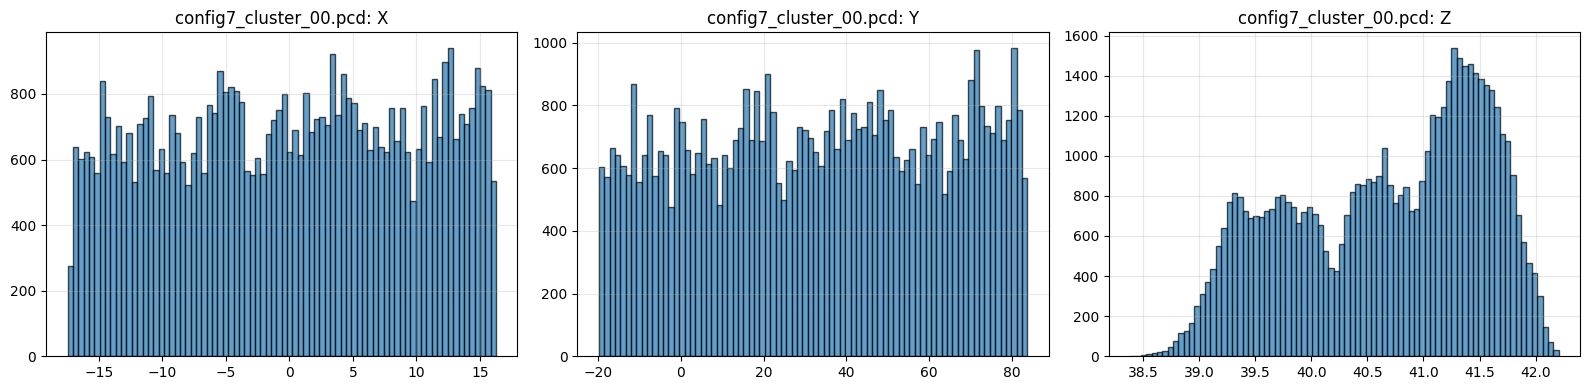

PointCloud with 55416 points.

In [18]:
inspect_pcd_file(os.path.join(OUT_DIR, "config7_cluster_00.pcd"), show_hist=True)

#### IR data

In [7]:
las_path  = "./DATASOURCE/2025-07-15-IR.laz"
df = point_cloud_to_dataframe(las_path)
    
print(df.head())
print(df.columns)

📂 Loading LAS/LAZ file: ./DATASOURCE/2025-07-15-IR.laz
Number of points: 11,165,589
Detected dimensions: ['X', 'Y', 'Z', 'intensity', 'return_number', 'number_of_returns', 'scan_direction_flag', 'edge_of_flight_line', 'classification', 'synthetic', 'key_point', 'withheld', 'scan_angle_rank', 'user_data', 'point_source_id', 'red', 'green', 'blue', 'confidence', 'normal x', 'normal y', 'normal z']
DataFrame created. Shape: (11165589, 22)
           X          Y       Z  intensity  return_number  number_of_returns  \
0  13.615321  45.272508  50.158          0              1                  1   
1  13.615325  45.272513  50.148          0              1                  1   
2  13.615323  45.272508  50.131          0              1                  1   
3  13.615323  45.272508  50.131          0              1                  1   
4  13.615325  45.272512  50.145          0              1                  1   

   scan_direction_flag  edge_of_flight_line  classification  synthetic  ...  \


#### Multispectral data

In [8]:
las_path  = "./DATASOURCE/LOCAL_VINEYARD_MS.las"
pcd_path = "./table_scene_lms400.pcd"
df = point_cloud_to_dataframe(las_path)

print(df.head())
print(df.columns)

📂 Loading LAS/LAZ file: ./DATASOURCE/LOCAL_VINEYARD_MS.las
Number of points: 18,557,364
Detected dimensions: ['X', 'Y', 'Z', 'intensity', 'return_number', 'number_of_returns', 'synthetic', 'key_point', 'withheld', 'overlap', 'scanner_channel', 'scan_direction_flag', 'edge_of_flight_line', 'classification', 'user_data', 'scan_angle', 'point_source_id', 'gps_time', 'red', 'green', 'blue', 'nir', 'normal z', 'normal y', 'normal x', 'confidence']
DataFrame created. Shape: (18557364, 26)
        X       Y       Z  intensity  return_number  number_of_returns  \
0  64.462  72.585  37.846          0              1                  1   
1  64.635  72.533  37.849          0              1                  1   
2  64.444  72.590  37.837          0              1                  1   
3  64.547  72.557  37.860          0              1                  1   
4  64.516  72.568  37.864          0              1                  1   

   synthetic  key_point  withheld  overlap  ...  point_source_id  g

#### LIDAR data

In [9]:
las_path  = "./DATASOURCE/2025-07-15-LIDAR-Maslina2.las"
df = point_cloud_to_dataframe(las_path)
    
print(df.head())
print(df.columns)

📂 Loading LAS/LAZ file: ./DATASOURCE/2025-07-15-LIDAR-Maslina2.las
Number of points: 99,899
Detected dimensions: ['X', 'Y', 'Z', 'intensity', 'return_number', 'number_of_returns', 'synthetic', 'key_point', 'withheld', 'overlap', 'scanner_channel', 'scan_direction_flag', 'edge_of_flight_line', 'classification', 'user_data', 'scan_angle', 'point_source_id', 'gps_time', 'red', 'green', 'blue', 'nir', 'distance', 'height above ground', 'beam id']
DataFrame created. Shape: (99899, 25)
            X            Y       Z  intensity  return_number  \
0  273502.493  5018696.740  36.884       2304              2   
1  273502.809  5018696.663  36.940       1024              2   
2  273503.377  5018696.528  36.793       1024              2   
3  273503.618  5018696.469  36.920       2304              1   
4  273503.281  5018693.870  36.951       1024              2   

   number_of_returns  synthetic  key_point  withheld  overlap  ...  \
0                  2          0          0         0        

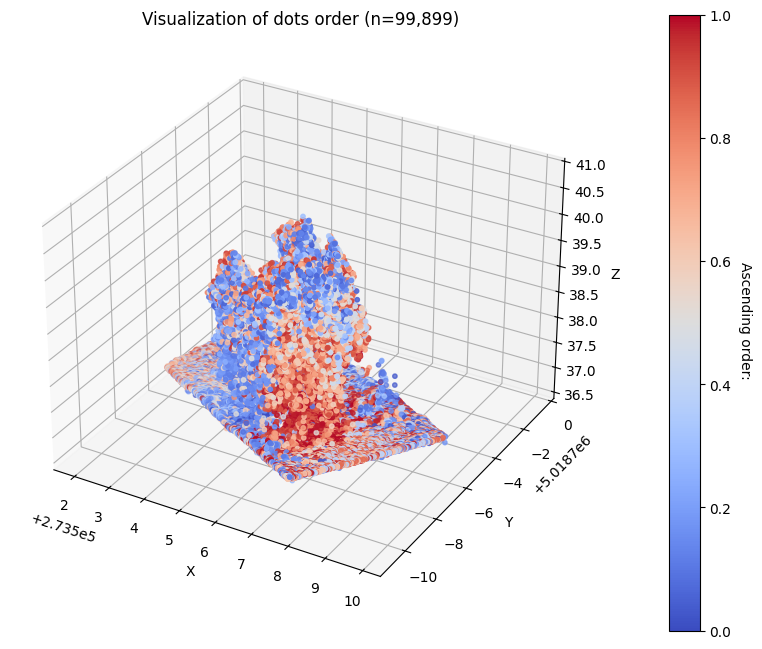

In [10]:
plot_point_cloud_points(df)

In [11]:
def plot_points_above_threshold(df, threshold=0.5, cmap="viridis", point_size=10):
    """
    Displays a 3D scatter plot of points from a DataFrame that are above a specified height-above-ground threshold.

    Parameters:
    df (pandas.DataFrame): Must contain columns 'X', 'Y', 'Z', and 'height above ground'.

    threshold (float, default=0.5): Height-above-ground threshold; points with height greater than this value are shown.

    cmap (str, default='viridis'): Colormap name for coloring points by height.

    point_size (int, default=10): Point size in the scatter plot.

    Return value:
    None — the function only displays the plot and prints the minimum and maximum height above ground.
    """

    above_ground = df[df["height above ground"] > threshold]

    X2 = above_ground["X"].values
    Y2 = above_ground["Y"].values
    Z2 = above_ground["Z"].values
    height2 = above_ground["height above ground"].values

    h_min2, h_max2 = np.min(height2), np.max(height2)
    print(f"Minimum height above field: {h_min2:.3f}")
    print(f"Maximum height above field: {h_max2:.3f}")

    fig = plt.figure(figsize=(10, 8))
    ax = fig.add_subplot(111, projection="3d")

    sc = ax.scatter(X2, Y2, Z2, c=height2, cmap=cmap, s=point_size)

    cbar = plt.colorbar(sc, ax=ax, pad=0.1)
    cbar.set_label("Height above ground (normalized)", rotation=270, labelpad=15)

    ax.set_xlabel("X")
    ax.set_ylabel("Y")
    ax.set_zlabel("Z")
    ax.set_title(f"Dots above {threshold} m (vegetations)")

    plt.show()

Minimum height above field: 1.010
Maximum height above field: 3.800


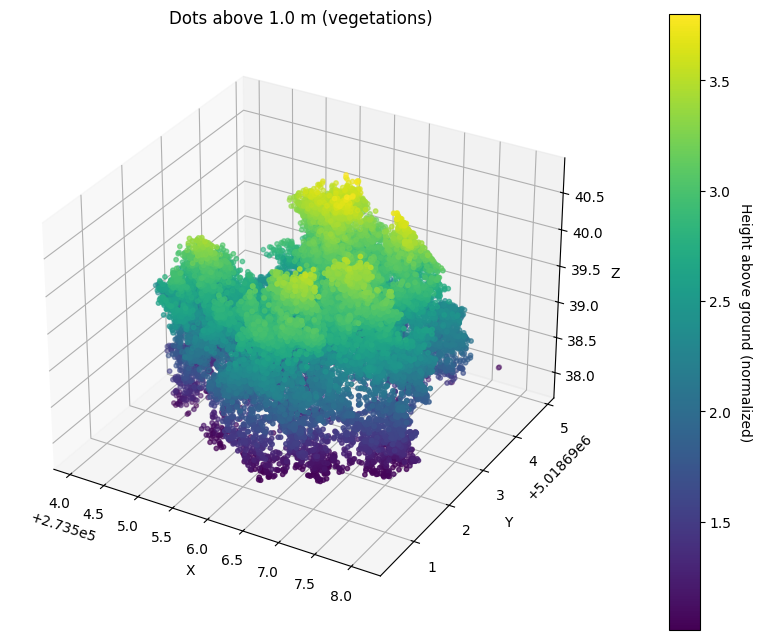

In [12]:
plot_points_above_threshold(df, threshold=1.0)

In [13]:
import laspy
import numpy as np

def export_filtered_las(df, las, output_path):
    new_header = laspy.LasHeader(
        point_format=las.header.point_format.id,
        version=las.header.version
    )

    new_las = laspy.LasData(new_header)

    new_las.X = df["X"].astype(np.int32)
    new_las.Y = df["Y"].astype(np.int32)
    new_las.Z = df["Z"].astype(np.int32)

    for col in df.columns:
        if col in new_las.point_format.dimension_names:
            if col not in ["X", "Y", "Z"]:
                setattr(new_las, col, df[col].values)
        else:
            print(f"Column - '{col}' (is not standard LAS dimension)")

    new_las.write(output_path)

    print("New LAS file successfully saved!")
    print(f"Path: {output_path}")
    print(f"Scale factors: {new_las.header.scales}")
    print(f"Offsets: {new_las.header.offsets}")
    print(f"Number of points: {len(new_las.X)}")


    return new_las


In [14]:
filtered_df = df[df["height above ground"] > 0.5]
output_path = "./DATASOURCE/filtered_output.las"
las = laspy.read("./DATASOURCE/2025-07-15-LIDAR-Maslina2.las")

new_las = export_filtered_las(df, las, output_path)

Column - 'distance' (is not standard LAS dimension)
Column - 'height above ground' (is not standard LAS dimension)
Column - 'beam id' (is not standard LAS dimension)
New LAS file successfully saved!
Path: ./DATASOURCE/filtered_output.las
Scale factors: [0.01 0.01 0.01]
Offsets: [0. 0. 0.]
Number of points: 99899


In [15]:
df = point_cloud_to_dataframe("./DATASOURCE/filtered_output.las")

print(df.head())
print(df.columns)

📂 Loading LAS/LAZ file: ./DATASOURCE/filtered_output.las
Number of points: 99,899
Detected dimensions: ['X', 'Y', 'Z', 'intensity', 'return_number', 'number_of_returns', 'synthetic', 'key_point', 'withheld', 'overlap', 'scanner_channel', 'scan_direction_flag', 'edge_of_flight_line', 'classification', 'user_data', 'scan_angle', 'point_source_id', 'gps_time', 'red', 'green', 'blue', 'nir']
DataFrame created. Shape: (99899, 22)
         X         Y     Z  intensity  return_number  number_of_returns  \
0  2735.02  50186.96  0.36       2304              2                  2   
1  2735.02  50186.96  0.36       1024              2                  2   
2  2735.03  50186.96  0.36       1024              2                  2   
3  2735.03  50186.96  0.36       2304              1                  1   
4  2735.03  50186.93  0.36       1024              2                  2   

   synthetic  key_point  withheld  overlap  ...  edge_of_flight_line  \
0          0          0         0        0  ... 

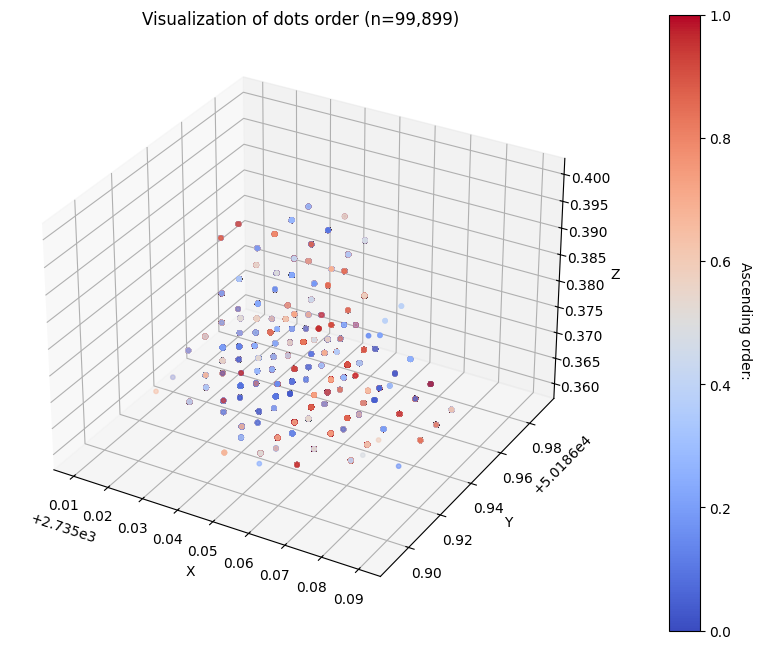

In [16]:
plot_point_cloud_points(df)

### Voxelization
This step converts points into voxels of a defined resolution to reduce point cloud density.

In [17]:
import plotly.graph_objects as go
import open3d as o3d

def show_pcd_plotly(pcd: o3d.geometry.PointCloud, marker_size=2):
    P = np.asarray(pcd.points)
    if P.size == 0:
        raise ValueError("PointCloud is empty.")
    if pcd.has_colors():
        C = (np.asarray(pcd.colors) * 255).astype(np.uint8)
        col = [f"rgb({r},{g},{b})" for r,g,b in C]
    else:
        col = "rgb(0,120,255)"

    fig = go.Figure(data=[go.Scatter3d(
        x=P[:,0], y=P[:,1], z=P[:,2],
        mode="markers",
        marker=dict(size=marker_size, color=col, opacity=0.95)
    )])
    fig.update_layout(scene_aspectmode="data", margin=dict(l=0,r=0,t=0,b=0))
    fig.show()


def show_voxelgrid_plotly(vg: o3d.geometry.VoxelGrid, marker_size=3):
    #Takes each voxel from the Open3D VoxelGrid

    #Computes its real XYZ center

    #Retrieves the voxel’s color (if available)

    #Converts the color into a Plotly-compatible format

    #Plots all voxels in 3D as colored points in an interactive Plotly view

    voxels = vg.get_voxels()
    if len(voxels) == 0:
        raise ValueError("VoxelGrid is empty.")
    
    # Centers calculation
    centers = np.array([vg.get_voxel_center_coordinate(v.grid_index) for v in voxels])

    colors = []
    for v in voxels:
        if hasattr(v, "color") and v.color is not None:
            c = (np.asarray(v.color) * 255).astype(np.uint8)
            colors.append(f"rgb({c[0]},{c[1]},{c[2]})")
        else:
            colors.append("rgb(200,200,200)")
    fig = go.Figure(data=[go.Scatter3d(
        x=centers[:,0], y=centers[:,1], z=centers[:,2],
        mode="markers",
        marker=dict(size=marker_size, color=colors, opacity=0.95)
    )])
    fig.update_layout(scene_aspectmode="data", margin=dict(l=0,r=0,t=0,b=0))
    fig.show()

Method for visualization using OffscreenRenderer - not important for voxelization algorithm

In [18]:
def render_geometry_offscreen(geom, width=1280, height=720, shader="defaultUnlit"):
    import open3d as o3d, numpy as np
    from matplotlib import pyplot as plt

    renderer = o3d.visualization.rendering.OffscreenRenderer(width, height)
    mat = o3d.visualization.rendering.MaterialRecord()
    mat.shader = shader
    renderer.scene.add_geometry("obj", geom, mat)

    aabb = geom.get_axis_aligned_bounding_box()
    center = aabb.get_center().astype(np.float32)
    eye = center + np.array([0, 0, 2.5*np.linalg.norm(aabb.get_extent())], dtype=np.float32)
    up = np.array([0, 1, 0], dtype=np.float32)
    renderer.setup_camera(60.0, center, eye, up)

    img = renderer.render_to_image()
    plt.imshow(np.asarray(img))
    plt.axis("off")
    plt.show()


#### Algorithm implementation

In [37]:
las_path  = "./DATASOURCE/2025-07-15-LIDAR-Maslina2.las"

In [38]:
point_cloud = laspy.read(las_path)
xyz = np.vstack((point_cloud.x, point_cloud.y, point_cloud.z)).T.astype(np.float32)
rgb = np.vstack((point_cloud.red, point_cloud.green, point_cloud.blue)).transpose()/65535

In [39]:
pcd = o3d.geometry.PointCloud()

In [40]:
pcd.points = o3d.utility.Vector3dVector(xyz)
pcd.colors = o3d.utility.Vector3dVector(rgb)

In [41]:
vsize = max(pcd.get_max_bound()-pcd.get_min_bound())*0.01
vsize = round(vsize,4)
vsize = 0.5

In [42]:
print(np.asarray(pcd.points).shape)

(99899, 3)


In [43]:
pcd_reduced = pcd.voxel_down_sample(voxel_size=vsize)

voxel_grid=o3d.geometry.VoxelGrid.create_from_point_cloud(pcd_reduced, voxel_size=vsize)
min_bound = voxel_grid.get_min_bound()
max_bound = voxel_grid.get_max_bound()
bounds = max_bound - min_bound
print("Min coordinates:", min_bound)
print("Max coordinates:", max_bound)
print("Bounds:", bounds)
print("Voxel numbers:", len(voxel_grid.get_voxels()))

Min coordinates: [2.73501812e+05 5.01868875e+06 3.65460014e+01]
Max coordinates: [2.73509812e+05 5.01869975e+06 4.10460014e+01]
Bounds: [ 8.  11.   4.5]
Voxel numbers: 437


In [44]:
voxel_grid = o3d.geometry.VoxelGrid.create_from_point_cloud(pcd, voxel_size=vsize)
print("Number of voxels:", len(voxel_grid.get_voxels()))

Number of voxels: 604


In [45]:
bounds=voxel_grid.get_max_bound()-voxel_grid.get_min_bound()

In [46]:
o3d.visualization.draw_geometries([voxel_grid])

[Open3D INFO] EGL headless mode enabled.
FEngine (64 bits) created at 0x56820d8412f0 (threading is enabled)
EGL(1.5)
OpenGL(4.6)


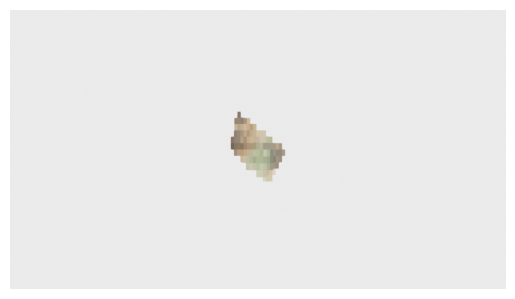

In [47]:
render_geometry_offscreen(voxel_grid)

Voxelgrid with full PCD

In [48]:
show_voxelgrid_plotly(voxel_grid, marker_size=4)
print(len(voxel_grid.get_voxels()))

604


Voxelgrid with reduced PCD

In [49]:
voxel_grid_reduced = o3d.geometry.VoxelGrid.create_from_point_cloud(pcd_reduced, voxel_size=vsize)
show_voxelgrid_plotly(voxel_grid_reduced, marker_size=4)

Minimal distance between voxel centers

In [50]:
import numpy as np
import open3d as o3d

voxels = voxel_grid.get_voxels()
centers = np.array([
    voxel_grid.get_voxel_center_coordinate(v.grid_index)
    for v in voxels
])

X = centers[:, 0]
Y = centers[:, 1]
Z = centers[:, 2]
n = len(centers)

min_dx = float("inf")
min_dy = float("inf")
min_dz = float("inf")
min_dist_xy = float("inf")
min_dist_xyz = float("inf")

pair_dx = pair_dy = pair_dz = pair_xy = pair_xyz = (None, None)

for i in range(n):
    for j in range(i+1, n):

        dx = abs(X[i] - X[j])
        dy = abs(Y[i] - Y[j])
        dz = abs(Z[i] - Z[j])

        dist_xy = np.hypot(dx, dy)
        dist_xyz = np.linalg.norm(centers[i] - centers[j])

        if dx < min_dx:
            min_dx = dx
            pair_dx = (i, j)

        if dy < min_dy:
            min_dy = dy
            pair_dy = (i, j)

        if dz < min_dz:
            min_dz = dz
            pair_dz = (i, j)

        if dist_xy < min_dist_xy:
            min_dist_xy = dist_xy
            pair_xy = (i, j)

        if dist_xyz < min_dist_xyz:
            min_dist_xyz = dist_xyz
            pair_xyz = (i, j)

def show_pair(name, pair, value):
    i, j = pair
    print(f"\n{name}: {value}")
    print("  Voxel A:", centers[i])
    print("  Voxel B:", centers[j])

show_pair("Min 3D (XYZ) distance", pair_xyz, min_dist_xyz)



Min 3D (XYZ) distance: 0.5
  Voxel A: [2.73507469e+05 5.01869300e+06 3.86689987e+01]
  Voxel B: [2.73506969e+05 5.01869300e+06 3.86689987e+01]


Voxmesh even if it's not ideal for volume aprox.

In [51]:
import open3d as o3d
import numpy as np

def voxelgrid_to_cubes(voxel_grid, cube_size):
    voxels = voxel_grid.get_voxels()
    centers = np.array([
        voxel_grid.get_voxel_center_coordinate(v.grid_index)
        for v in voxels
    ])

    cube_list = []

    for v, center in zip(voxels, centers):
        cube = o3d.geometry.TriangleMesh.create_box(width=cube_size,
                                                    height=cube_size,
                                                    depth=cube_size)
        cube.translate(center - np.array([cube_size/2,
                                          cube_size/2,
                                          cube_size/2]))

        #Use voxel if has a color
        if hasattr(v, "color") and v.color is not None:
            cube.paint_uniform_color(v.color)
        else:
            cube.paint_uniform_color([0.6, 0.6, 0.6])

        cube_list.append(cube)

    # Connect all cubes in geometry
    full_mesh = o3d.geometry.TriangleMesh()
    for mesh in cube_list:
        full_mesh += mesh

    full_mesh.compute_vertex_normals()
    return full_mesh


cube_size = 0.5   # minimal voxel distance 
mesh = voxelgrid_to_cubes(voxel_grid, cube_size)

#o3d.visualization.draw(mesh)


def o3d_mesh_to_plotly(mesh, color=(150, 150, 150)):
    # Extract vertices and triangles
    verts = np.asarray(mesh.vertices)
    tris = np.asarray(mesh.triangles)

    # Convert color to RGB (0-255)
    r, g, b = color
    color_str = f"rgb({r},{g},{b})"

    # Create Plotly Mesh3D
    fig = go.Figure(data=[
        go.Mesh3d(
            x=verts[:, 0],
            y=verts[:, 1],
            z=verts[:, 2],
            i=tris[:, 0],
            j=tris[:, 1],
            k=tris[:, 2],
            color=color_str,
            opacity=1.0,
            flatshading=True
        )
    ])

    fig.update_layout(
        scene=dict(aspectmode="data"),
        width=900,
        height=700,
        margin=dict(l=0, r=0, t=0, b=0)
    )

    fig.show()

o3d_mesh_to_plotly(mesh, color=(180, 180, 220))
N = len(voxel_grid.get_voxels())
print(N)
print(vsize)
volume = N * (vsize ** 3)
print("Volume (m³):", volume)

604
0.5
Volume (m³): 75.5


In [52]:
len(voxel_grid.get_voxels())

604

### Custom voxelization 

In [53]:
import numpy as np
from collections import defaultdict

# 
# 1) COMPUTE MEAN DISTANCE BETWEEN POINTS (WITHOUT OUTLIERS)
# 
def mean_point_spacing(points, k=10, percentile_cut=95):
    """
    Computes mean nearest-neighbor distance without outliers.
    points: Nx3 numpy array
    k: number of neighbors to consider for spacing
    percentile_cut: remove distances above this percentile
    """
    N = points.shape[0]
    distances = []

    for i in range(N):
        # Compute distance to all points (brutal but simple)
        d = np.linalg.norm(points - points[i], axis=1)
        d = np.sort(d)[1:k+1]  # ignore zero distance to itself
        distances.extend(d)

    distances = np.array(distances)

    # Remove outliers
    cutoff = np.percentile(distances, percentile_cut)
    distances_filtered = distances[distances < cutoff]

    return distances_filtered.mean()


# 
# 2) VOXELIZATION USING MEAN DISTANCE AS VOXEL SIZE
#    + REMOVE POINTS ONCE A VOXEL IS CREATED
# 

def voxelize_custom(points, voxel_size):
    """
    Custom voxelization: 
    - creates a voxel only once for each (i,j,k)
    - removes all points inside a voxel once voxel is created
    
    Returns:
    voxel_dict = {(i,j,k): voxel_center}
    remaining_points = points NOT consumed (optional)
    """

    min_bound = points.min(axis=0)
    voxel_dict = {}
    consumed = set()

    for idx, p in enumerate(points):
        # Skip point if already consumed
        if idx in consumed:
            continue

        # Compute voxel index
        voxel_index = tuple(np.floor((p - min_bound) / voxel_size).astype(int))

        # Create voxel if doesn't exist
        if voxel_index not in voxel_dict:

            # Compute voxel center
            voxel_center = min_bound + (np.array(voxel_index) + 0.5) * voxel_size
            voxel_dict[voxel_index] = voxel_center

            # Remove all other points inside this voxel
            # (vectorized check)
            diffs = (points - min_bound) / voxel_size
            indices = np.floor(diffs).astype(int)
            mask = np.all(indices == voxel_index, axis=1)

            for j in np.where(mask)[0]:
                consumed.add(j)

    remaining = points[[i for i in range(len(points)) if i not in consumed]]
    return voxel_dict, remaining


# 
# EXAMPLE USAGE
# 

def custom_voxel_pipeline(pcd):
    points = np.asarray(pcd.points)

    #compute spacing
    mean_dist = mean_point_spacing(points)
    print("Mean spacing (voxel size):", mean_dist)

    #voxelization
    voxels, remaining = voxelize_custom(points, mean_dist)
    print("Created voxels:", len(voxels))
    print("Remaining points:", len(remaining))

    return voxels, mean_dist


In [55]:
voxels, mean_dist = custom_voxel_pipeline(pcd)

KeyboardInterrupt: 

In [57]:
def voxel_dict_to_cube_mesh(voxel_dict, voxel_size):
    meshes = []
    half = voxel_size / 2.0

    for center in voxel_dict.values():
        cube = o3d.geometry.TriangleMesh.create_box(voxel_size, voxel_size, voxel_size)
        cube.translate(center - np.array([half, half, half]))
        cube.compute_vertex_normals()
        meshes.append(cube)

    # connect all in one mesh geometry
    full_mesh = meshes[0]
    for m in meshes[1:]:
        full_mesh += m

    return full_mesh

In [58]:
voxels, mean_dist = custom_voxel_pipeline(pcd)

mesh = voxel_dict_to_cube_mesh(voxels, mean_dist)

cube_size = 0.0175 

o3d_mesh_to_plotly(mesh, color=(180, 180, 220))
N = len(voxel_grid.get_voxels())
print(N)
print(vsize)
volume = N * (vsize ** 3)
print("Volumen (m³):", volume)

KeyboardInterrupt: 

### Voxelization using -> (Open3D 0.19.0. documentation)

In [ ]:
pcd.scale(1 / np.max(pcd.get_max_bound() - pcd.get_min_bound()),
          center=pcd.get_center())
pcd.colors = o3d.utility.Vector3dVector(np.random.uniform(0, 1, size=(N, 3)))
o3d.visualization.draw_geometries([pcd])

print('voxelization')
voxel_grid = o3d.geometry.VoxelGrid.create_from_point_cloud(pcd,
                                                            voxel_size=0.05)
o3d.visualization.draw_geometries([voxel_grid])

voxelization
